In [ ]:
# Customer Segmentation using K-Means

## Data Preprocessing
## Elbow Method
## Clustering
## Results

In [1]:
from google.colab import files
uploaded = files.upload()

Saving new_raw_data.csv to new_raw_data.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv("new_raw_data.csv")
df.head()

,Timestamp,Q1. Age Group,Q2. Gender,Q3. Occupation,Q4. Monthly Income Range,Q5. Which e-commerce platforms do you use?,Q6. Primary platform you use most often,Q7. How often do you shop online?,Q8. Average monthly spending on e-commerce,Q9. What type of products do you buy most?,...,Q11. What influences your purchase decision the most?,Q12. Do you compare prices across platforms before buying?,Q13. Rate your satisfaction with your primary platform,Q14. Importance of price in choosing platform,Q15. Importance of delivery speed,Q16. Importance of product variety,Q17. Importance of return/refund policy,Q18. Have you faced delivery issues?,Q19. Preferred delivery time,Q20. Preferred payment method
0,3/25/2026 12:37:46,18 - 30,Male,Student,< 10000,Flipkart,Flipkart,Rarely,< 1000,Clothing,...,Price,Always,4,4,4,4,5,Yes,1 - 3 days,COD
1,3/25/2026 12:43:01,18 - 30,Male,Student,< 10000,"Amazon, Flipkart, Myntra",Amazon,Rarely,< 1000,Electronics,...,Reviews,Always,5,4,3,4,5,Yes,1 - 3 days,UPI
2,3/25/2026 12:43:45,> 50,Male,Other,> 100000,"Amazon, Flipkart, Others",Flipkart,Weekly,3000 - 7000,Groceries,...,Reviews,Always,4,4,4,5,5,Yes,1 - 3 days,Debit/Credit card
3,3/25/2026 12:44:51,> 50,Female,Working Professional,> 100000,"Amazon, Flipkart, Meesho, Myntra, Ajio",Amazon,Monthly,1000 - 3000,Clothing,...,Reviews,Sometimes,5,4,3,5,5,Yes,3 - 7 days,UPI
4,3/25/2026 12:45:00,18 - 30,Male,Student,< 10000,"Amazon, Flipkart, Meesho, Myntra, Ajio",Amazon,Monthly,7000+,Groceries,...,Brand,Always,5,5,5,5,5,No,1 - 3 days,UPI


In [5]:
df.columns = [
    "timestamp","age","gender","occupation","income",
    "platforms_used","primary_platform","shopping_frequency",
    "monthly_spending","primary_category","secondary_category",
    "purchase_factor","price_compare","satisfaction",
    "price_importance","delivery_importance",
    "variety_importance","return_importance",
    "delivery_issue","delivery_days","payment_method"
]

In [6]:
df["age"] = df["age"].replace({
    "< 18": 15, "18 - 30": 24, "30 - 50": 40, "> 50": 60
})

df["income"] = df["income"].replace({
    "< 10000": 5000, "10000-30000": 20000,
    "30000-60000": 45000, "60000-100000": 80000,
    "> 100000": 120000
})

df["shopping_frequency"] = df["shopping_frequency"].replace({
    "Daily": 30, "Weekly": 12, "Monthly": 4, "Rarely": 1
})

df["monthly_spending"] = df["monthly_spending"].replace({
    "< 1000": 800, "1000 - 3000": 2000,
    "3000 - 7000": 5000, "7000+": 8000
})

/tmp/ipykernel_1543/4013782955.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["age"] = df["age"].replace({
/tmp/ipykernel_1543/4013782955.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["income"] = df["income"].replace({
/tmp/ipykernel_1543/4013782955.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

In [7]:
cols = ["age", "income", "monthly_spending", "shopping_frequency","satisfaction"]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [8]:
df[cols] = df[cols].fillna(df[cols].mean())

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cols])

In [10]:
from sklearn.decomposition import KernelPCA

In [11]:
kpca = KernelPCA(n_components=2, kernel='rbf')

X_kpca = kpca.fit_transform(X_scaled)

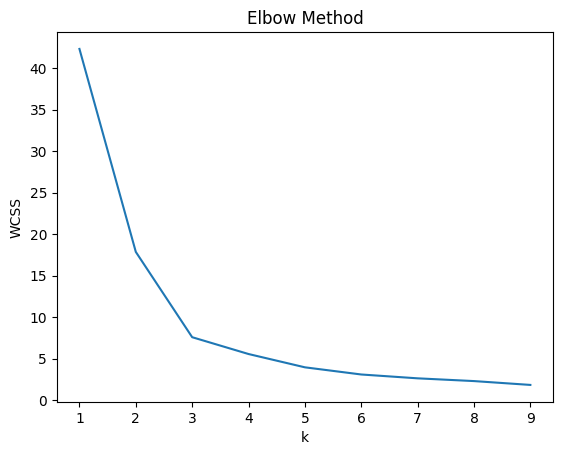

In [12]:
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_kpca)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss)
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [13]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42)
df["cluster"] = kmeans.fit_predict(X_kpca)

df.head()

,timestamp,age,gender,occupation,income,platforms_used,primary_platform,shopping_frequency,monthly_spending,primary_category,...,price_compare,satisfaction,price_importance,delivery_importance,variety_importance,return_importance,delivery_issue,delivery_days,payment_method,cluster
0,3/25/2026 12:37:46,24,Male,Student,5000,Flipkart,Flipkart,1,800,Clothing,...,Always,4,4,4,4,5,Yes,1 - 3 days,COD,1
1,3/25/2026 12:43:01,24,Male,Student,5000,"Amazon, Flipkart, Myntra",Amazon,1,800,Electronics,...,Always,5,4,3,4,5,Yes,1 - 3 days,UPI,1
2,3/25/2026 12:43:45,60,Male,Other,120000,"Amazon, Flipkart, Others",Flipkart,12,5000,Groceries,...,Always,4,4,4,5,5,Yes,1 - 3 days,Debit/Credit card,0
3,3/25/2026 12:44:51,60,Female,Working Professional,120000,"Amazon, Flipkart, Meesho, Myntra, Ajio",Amazon,4,2000,Clothing,...,Sometimes,5,4,3,5,5,Yes,3 - 7 days,UPI,2
4,3/25/2026 12:45:00,24,Male,Student,5000,"Amazon, Flipkart, Meesho, Myntra, Ajio",Amazon,4,8000,Groceries,...,Always,5,5,5,5,5,No,1 - 3 days,UPI,0


In [14]:
cluster_summary = df.groupby("cluster")[[
    "age","income","monthly_spending","shopping_frequency","satisfaction"
]].mean()

cluster_summary

,age,income,monthly_spending,shopping_frequency,satisfaction
cluster,,,,,
0,48.565217,86630.434783,5573.913043,10.434783,4.217391
1,24.952381,14365.079365,1495.238095,3.174603,3.936508
2,56.744186,110930.232558,1832.558140,3.813953,3.581395


In [16]:
def label_cluster(row):
    if row["cluster"] == 0:
        return "High Value Customers: Working professionals"
    elif row["cluster"] == 1:
        return "Low value Customers : Students"
    else:
        return "Potential Customers : Senior citizens"

df["customer_segment"] = df.apply(label_cluster, axis=1)

In [17]:
df[["cluster", "customer_segment"]].head()

,cluster,customer_segment
0,1,Low value Customers : Students
1,1,Low value Customers : Students
2,0,High Value Customers: Working professionals
3,2,Potential Customers : Senior citizens
4,0,High Value Customers: Working professionals


In [18]:
df.to_csv("clustered_data_final_data.csv", index=False)

In [19]:
cluster_summary = df.groupby("cluster")[[
    "age","income","monthly_spending","shopping_frequency","satisfaction"
]].mean()

cluster_summary

,age,income,monthly_spending,shopping_frequency,satisfaction
cluster,,,,,
0,48.565217,86630.434783,5573.913043,10.434783,4.217391
1,24.952381,14365.079365,1495.238095,3.174603,3.936508
2,56.744186,110930.232558,1832.558140,3.813953,3.581395


In [20]:
mapping = {
    0: "High Value Customers : Working professionals",
    1: "Low value Customers : Students",
    2: "Potential Customers : Senior citizens",

}

df["customer_segment"] = df["cluster"].map(mapping)

In [21]:
df["customer_segment"].value_counts()

,count
customer_segment,
Low value Customers : Students,63
High Value Customers : Working professionals,46
Potential Customers : Senior citizens,43


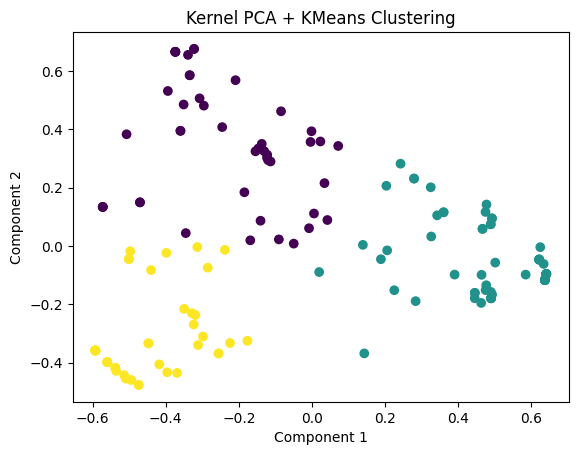

In [22]:
# -----------------------------
# VISUALIZATION
# -----------------------------
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=df["cluster"])
plt.title("Kernel PCA + KMeans Clustering")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

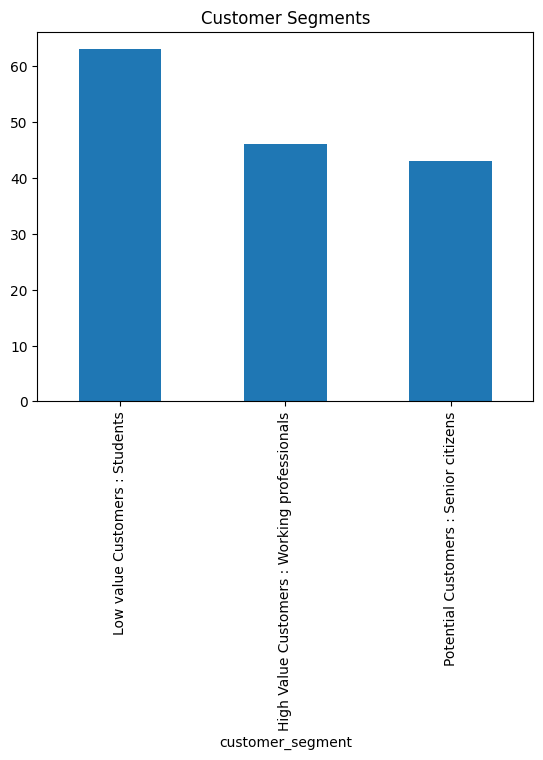

In [23]:
import matplotlib.pyplot as plt

df["customer_segment"].value_counts().plot(kind="bar")
plt.title("Customer Segments")
plt.show()

In [24]:
files.download("clustered_data_final_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>